# Titanic Survival Prediction

## Objective
Predict whether a passenger survived the Titanic disaster using machine learning.

---Understand the Dataset & Cleanup (if required).
---Build a strong classification model to predict whether the passenger survives or not.
---Also fine-tune the hyperparameters and for now only use Logistic Regression.

# 1. Problem Understanding

---Problem Type: Binary Classfication
---Target Variable: Survived
---Goal: Predict whether a passenger survided using passenger other information.


# 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# 3. Load the Dataset (Getting the data)

In [2]:
df=pd.read_csv("../data/raw/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4. Initial Data Exploration

In [3]:
df.shape

(891, 12)

In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observations

- The dataset contains **891 rows** and **12 columns**.
- `Survived` is the target variable for this binary classification problem.
- The dataset contains both **numerical** and **categorical** features.
- `Age`, `Cabin`, and `Embarked` contain missing values.
- `Cabin` has a large number of missing values and will require special handling during preprocessing.
- `PassengerId` appears to be a unique identifier and is unlikely to be useful for prediction.
- The `Age` and `Fare` columns are continuous numerical features, while `Pclass`, `SibSp`, and `Parch` are discrete numerical features.
- Categorical features such as `Sex`, `Embarked`, and `Cabin` will need to be encoded before training the model.
- No obvious issues are observed in the remaining columns during the initial inspection.
- We can also see that scale of `Age` and `Fare` have major difference so we need to scale before training.

# 5. Create a Stratified Train/Test Split

To prevent data leakage, we split the dataset into training and test sets before performing detailed exploratory data analysis (EDA) or data preprocessing.

Since this is a binary classification problem, we use **stratified sampling** to preserve `Survived` in both the training and test sets.

In [5]:
from sklearn.model_selection import train_test_split
X=df.drop("Survived",axis=1)
y=df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 11) (179, 11) (712,) (179,)


### Observations

- The dataset has been split into training and test sets.
- Approximately 80% of the data is used for training and 20% for testing.
- Stratified sampling ensures that the proportion of survived and non-survived passengers is maintained in both sets.
- The test set will remain untouched until the final evaluation to prevent data leakage.### Observations

- The dataset has been split into training and test sets.
- Approximately 80% of the data is used for training and 20% for testing.
- Stratified sampling ensures that the proportion of survived and non-survived passengers is maintained in both sets.
- The test set will remain untouched until the final evaluation to prevent data leakage.

# 6. Exploratory Data Analysis (EDA)

In this section, we explore the training dataset to understand feature distributions, identify relationships between features and the target variable, and gather insights that will guide feature engineering and data preprocessing.

The test set is intentionally left untouched to prevent data leakage.

In [6]:
train_set=X_train.copy()
train_set["Survived"]=y_train

## 6.1 Target Variable Distribution

Before analyzing the features, we first examine the distribution of the target variable (`Survived`). This helps us understand the class balance and identify whether the dataset is imbalanced.

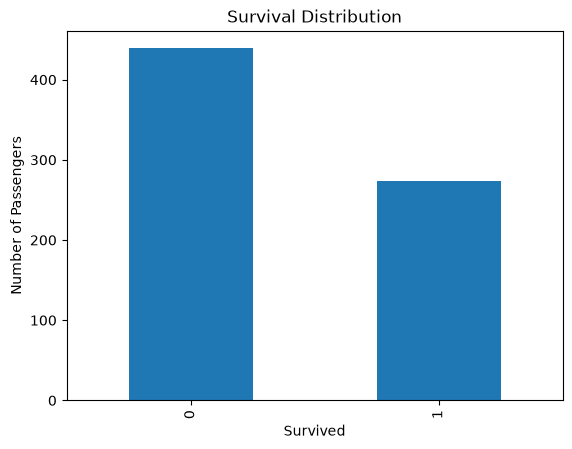

In [7]:
train_set["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")
plt.savefig("../outputs/plots/survival_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- The dataset is slightly imbalanced, with more non-survivors than survivors.
- However, the imbalance is not severe, so both classes are still well represented.
- At this stage, no special techniques for handling class imbalance appear to be necessary.

## 6.2 Age and fare Distribution

We visualize the distribution of passenger ages and fares to understand the spread of the data, identify skewness, detect possible outliers, and determine whether preprocessing (such as scaling or handling missing values) may be required.

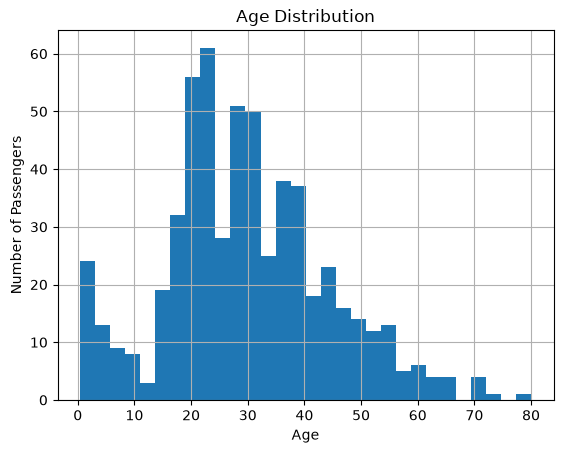

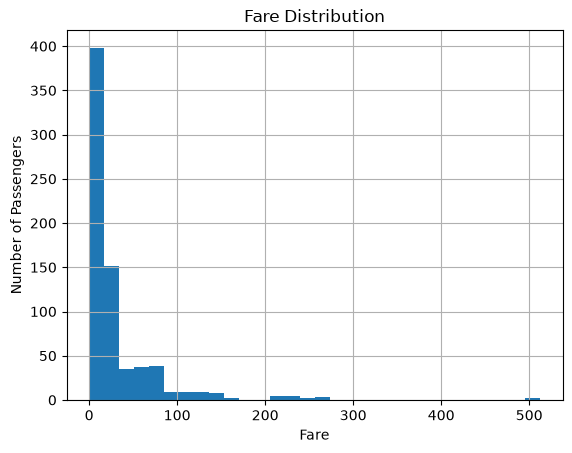

In [8]:
train_set["Age"].hist(bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.savefig("../outputs/plots/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
train_set["Fare"].hist(bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.savefig("../outputs/plots/fare_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- Most passengers are between **20–40 years** of age, with the `Age` distribution being **slightly right-skewed**.
- The `Fare` distribution is **heavily right-skewed**, with a few passengers paying significantly higher fares than the majority.
- `Fare` contains potential outliers due to these extremely high values.
- Both `Age` and `Fare` are numerical features and will be **standardized** during data preprocessing.
- The strong skewness in `Fare` suggests that a **log transformation** could be explored as a future improvement.

## 6.3 Categorical Feature Distribution

In this section, we examine the distribution of the categorical features to understand the composition of the dataset before analyzing their relationship with the target variable.

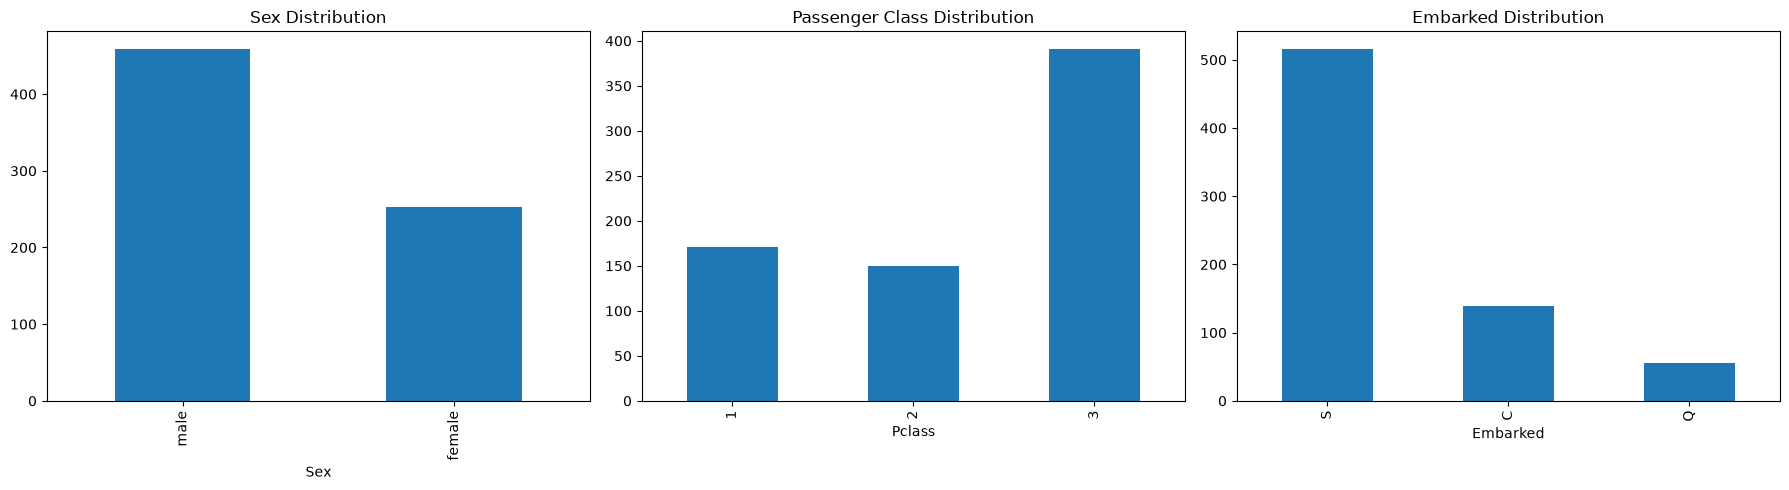

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_set["Sex"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    title="Sex Distribution"
)

train_set["Pclass"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    title="Passenger Class Distribution"
)

train_set["Embarked"].value_counts().plot(
    kind="bar",
    ax=axes[2],
    title="Embarked Distribution"
)

plt.tight_layout()
plt.savefig("../outputs/plots/categorical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- The dataset contains more **male** passengers than **female** passengers.
- Most passengers traveled in **3rd class**, followed by **1st class** and **2nd class**.
- Most passengers embarked from **Southampton (S)**, while fewer embarked from **Cherbourg (C)** and **Queenstown (Q)**.
- These categorical features may influence passenger survival and will be explored further by comparing them with the target variable.

## 6.3 Relationship Between Features and the Target Variable

In this section, we analyze how different features influence passenger survival. By comparing each feature with the target variable (`Survived`), we can identify which features are likely to be the most useful for prediction.

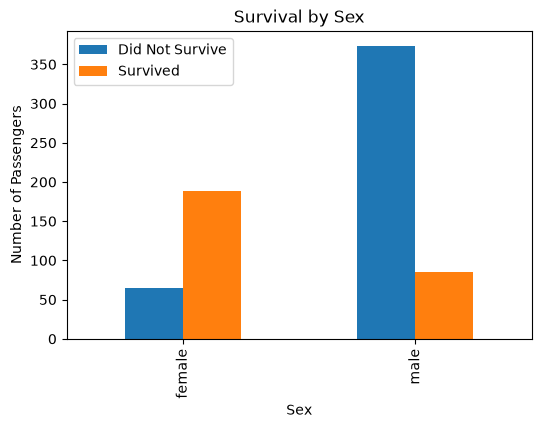

In [10]:
pd.crosstab(train_set["Sex"], train_set["Survived"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])
plt.savefig("../outputs/plots/survival_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()

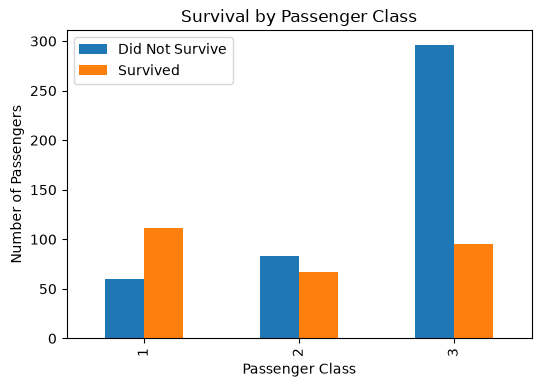

In [11]:
pd.crosstab(train_set["Pclass"], train_set["Survived"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])
plt.savefig("../outputs/plots/survival_by_passenger_class.png", dpi=300, bbox_inches="tight")
plt.show()

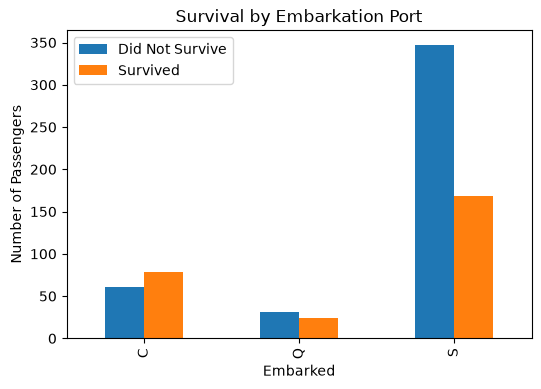

In [12]:
pd.crosstab(train_set["Embarked"], train_set["Survived"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Number of Passengers")
plt.legend(["Did Not Survive", "Survived"])
plt.savefig("../outputs/plots/survival_by_embarkation_port.png", dpi=300, bbox_inches="tight")
plt.show()

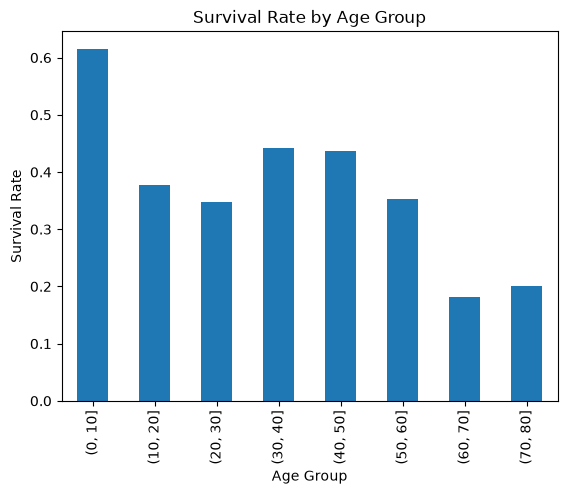

In [13]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]

train_set["AgeGroup"] = pd.cut(
    train_set["Age"],
    bins=age_bins
)
age_survival = train_set.groupby("AgeGroup")["Survived"].mean()
age_survival.plot(kind="bar")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.savefig("../outputs/plots/survival_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

### Overall Observations

- Female passengers had a significantly higher survival rate than male passengers, making `Sex` one of the strongest predictive features.
- Passengers traveling in **1st class** were more likely to survive than those in **2nd** and **3rd class**, indicating that `Pclass` is an important feature.
- Survival rates varied across embarkation ports, suggesting that `Embarked` may have some predictive value, although its impact appears weaker than `Sex` and `Pclass`.
- Younger passengers, particularly children, showed a higher survival rate than older age groups, indicating that `Age` may also contribute to predicting survival.
- Overall, `Sex`, `Pclass`, and `Age` appear to be the most informative features identified during exploratory data analysis and should be retained for model training.

## 6.4 Correlation Analysis

We compute the correlation matrix to measure the strength and direction of linear relationships between numerical features and the target variable. This helps identify potentially useful features for model training.

In [14]:
correlation_matrix = train_set.corr(numeric_only=True)

correlation_matrix["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.275499
Parch          0.084178
PassengerId    0.011892
SibSp         -0.026115
Age           -0.084268
Pclass        -0.348007
Name: Survived, dtype: float64

### Observations

- `Pclass` shows the strongest negative correlation with survival, indicating that passengers in lower classes were less likely to survive.
- `Fare` has a positive correlation with survival, suggesting that passengers who paid higher fares tended to survive more often.
- `Age` has only a weak negative correlation with survival, indicating that age alone is not a strong linear predictor.
- Correlation measures only **linear relationships**, so features with low correlation may still be useful for the model.

## 6.5 Experimenting with Attribute Combinations(Trying out something)

Feature engineering involves creating new features from existing ones to provide additional information to the model. In this section, we create a new feature representing the total number of family members traveling together.

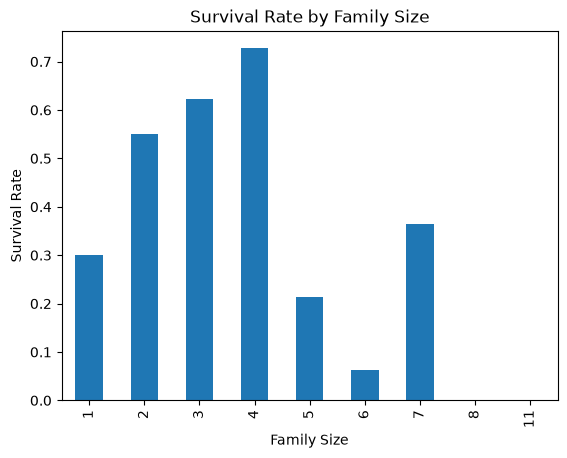

In [15]:
train_set["FamilySize"] = (
    train_set["SibSp"] +
    train_set["Parch"] +
    1
)
family_survival = train_set.groupby("FamilySize")["Survived"].mean()

family_survival.plot(kind="bar")

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.savefig("../outputs/plots/survival_by_family_size.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- Passengers traveling in small families (2–4 members) had higher survival rates than those traveling alone.
- Passengers traveling alone (Family Size = 1) had a comparatively lower survival rate.
- Survival rates generally declined for larger families (5 or more members), although these groups contained relatively few passengers.
- The `FamilySize` feature appears to capture useful information that is not directly available from `SibSp` and `Parch` individually, making it a potentially valuable engineered feature.

## 6.5 Correlation Analysis

After exploring the data and engineering the `FamilySize` feature, we compute the correlation matrix again to examine how the numerical features relate to the target variable (`Survived`).

This helps identify which numerical features are most useful for prediction.

In [16]:
correlation_matrix = train_set.corr(numeric_only=True)

correlation_matrix["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.275499
Parch          0.084178
FamilySize     0.026967
PassengerId    0.011892
SibSp         -0.026115
Age           -0.084268
Pclass        -0.348007
Name: Survived, dtype: float64

### Observations

- A new feature, `FamilySize`, was created by combining `SibSp` and `Parch`.
- Although the feature showed some interesting survival patterns during EDA, its linear correlation with `Survived` was weak.
- For this project, the original features will be retained, and `FamilySize` will not be used as a primary predictor.

# 6.6 EDA Summary

### Key Insights

- The dataset contains missing values in the `Age`, `Cabin`, and `Embarked` columns, which will need to be handled during data preprocessing.
- The target variable is slightly imbalanced, with more non-survivors than survivors; however, the imbalance is not severe enough to require special treatment.
- `Age` is slightly right-skewed, while `Fare` is heavily right-skewed and contains potential outliers.
- `Sex` and `Pclass` show the strongest relationship with passenger survival, making them important predictive features.
- `Embarked` appears to have some predictive value but is less influential than `Sex` and `Pclass`.
- Feature engineering with `FamilySize` revealed some interesting survival patterns, but its linear correlation with the target was weak, so it will not be used in this project.
- Based on the EDA, the next step is to preprocess the data by handling missing values, encoding categorical variables, scaling numerical features, and preparing the dataset for model training.

# 7. Data Preparation

In this section, we prepare the training data for machine learning by selecting relevant features, handling missing values, encoding categorical features, scaling numerical features, and building a preprocessing pipeline.

## 7.1 Identify Feature Types

Different features require different preprocessing techniques. We first separate numerical and categorical features so that the appropriate transformations can be applied to each group using a preprocessing pipeline.

In [17]:
numerical_features = [
    "Age",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

ordinal_features = [
    "Pclass"
]

remaining_features = [
    "SibSp",
    "Parch"
]

### Observations

- Numerical features will require imputation and feature scaling.
- Categorical features will require imputation and one-hot encoding.
- `Pclass` is treated as an ordinal feature because the values (1, 2, and 3) represent an ordered ranking rather than continuous numerical values.
- `SibSp` and `Parch` will be passed through without additional preprocessing.

## 7.2 Numerical Preprocessing Pipeline

The numerical preprocessing pipeline handles missing values and scales numerical features. This ensures that the model receives complete and standardized numerical data while allowing the same preprocessing steps to be applied automatically to future datasets.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## 7.3 Categorical Preprocessing Pipeline

The categorical preprocessing pipeline handles missing values and converts categorical features into a numerical format using One-Hot Encoding. This enables machine learning algorithms to work effectively with categorical data while ensuring the preprocessing can be reused for future datasets.

In [19]:
from sklearn.preprocessing import OneHotEncoder
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot_encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

### Observations

- Missing values in categorical features are replaced using the most frequent category.
- One-Hot Encoding converts categorical variables into numerical binary features without introducing artificial ordering.
- `drop="first"` removes one category from each feature to eliminate redundant columns and reduce multicollinearity.
- `handle_unknown="ignore"` ensures the preprocessing pipeline can safely handle unseen categories during inference without raising errors.

## 7.4 Column Transformer

The `ColumnTransformer` combines the numerical and categorical preprocessing pipelines into a single reusable preprocessing step. Each feature group is automatically sent through the appropriate transformations, while the remaining features are passed through unchanged.

In [20]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="drop"
)

## 7.5 Transform the Training Data

The preprocessing pipeline is now applied to the training data. This automatically performs missing value imputation, feature scaling, one-hot encoding, and combines all processed features into a format suitable for machine learning.

In [21]:
X_train_prepared = preprocessor.fit_transform(X_train)

### Observations

- The preprocessing pipeline was successfully fitted on the training data.
- Missing values were automatically imputed.
- Numerical features were standardized.
- Categorical features were converted into numerical binary features using One-Hot Encoding.
- The processed dataset is now ready for training the Logistic Regression model.

# 8. Model Training

## 8.1 Logistic Regression

Logistic Regression is trained using the preprocessed training data. During training, the model learns the relationship between the input features and the target variable (`Survived`) so that it can make predictions on unseen data.

In [22]:
print(X_train.columns)

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [23]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_prepared, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Observations

- The Logistic Regression model was successfully trained on the preprocessed training data.
- The model has learned patterns from the training data and is ready to make predictions on unseen data.
- Training is complete, but the model's performance must be evaluated using the test set to measure its ability to generalize.

## 8.2 Evaluate on the Training Set

After training the Logistic Regression model, we evaluate its performance on the training data. This provides an initial indication of how well the model has learned the underlying patterns before assessing its ability to generalize using cross-validation and the test set.

In [24]:
from sklearn.metrics import accuracy_score
train_predictions = log_reg.predict(X_train_prepared)
train_accuracy = accuracy_score(y_train, train_predictions)
print(f"Training Accuracy: {train_accuracy:.4f}") 

Training Accuracy: 0.7837


### Observations

- The Logistic Regression model achieved a training accuracy of **78.37%**.
- The model has successfully learned patterns from the training data.
- Training accuracy alone is not sufficient to judge model performance, as it is evaluated on data the model has already seen.
- Cross-validation will be performed next to estimate the model's ability to generalize to unseen data.

## 8.3 Cross Validation

Cross-validation provides a more reliable estimate of model performance by repeatedly training and validating the model on different subsets of the training data. This helps evaluate how well the model is expected to generalize to unseen data.

In [25]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    log_reg,
    X_train_prepared,
    y_train,
    cv=5,
    scoring="accuracy"
)
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of Cross-Validation Accuracy: {cv_scores.std():.4f}")

Cross-Validation Accuracy Scores: [0.76223776 0.76223776 0.78873239 0.80985915 0.78873239]
Mean Cross-Validation Accuracy: 0.7824
Standard Deviation of Cross-Validation Accuracy: 0.0182


### Observations

- The Logistic Regression model achieved a mean cross-validation accuracy of **78.24%**.
- The cross-validation accuracy is very close to the training accuracy (**78.37%**), suggesting that the model generalizes well and is not significantly overfitting.
- The standard deviation of **1.82%** indicates that the model performs consistently across different folds of the training data.
- Overall, the model demonstrates stable and reliable performance on the training dataset.

# 9. Fine-Tune the Model

After establishing a baseline Logistic Regression model, the next step is to improve its performance by tuning hyperparameters. Fine-tuning helps identify the combination of model settings that produces the best generalization performance while avoiding overfitting.

## 9.1 Hyperparameter Tuning

Hyperparameters are configuration settings specified before training a machine learning model. Unlike model parameters learned during training, hyperparameters control the learning process itself. In this project, we tune the Logistic Regression hyperparameter `C`, which controls the strength of regularization.

## 9.2 Grid Search

Grid Search systematically evaluates multiple combinations of hyperparameter values using cross-validation. It selects the combination that achieves the highest validation performance, allowing us to identify the best-performing Logistic Regression model.

In [26]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)
grid_search.fit(X_train_prepared, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Best Parameters: {'C': 0.1}
Best Cross-Validation Score: 0.7852


### Observations

- Grid Search identified **C = 0.1** as the optimal hyperparameter for the Logistic Regression model.
- The tuned model achieved a mean cross-validation accuracy of **78.52%**, improving slightly over the baseline model (**78.24%**).
- The lower value of `C` applies stronger regularization, suggesting that a simpler model provides better generalization on the Titanic dataset.

## 9.3 Final Evaluation on the Test Set

After selecting the best-performing Logistic Regression model using Grid Search, we evaluate it on the unseen test set. This provides an unbiased estimate of how well the final model generalizes to new data.

In [27]:
best_model = grid_search.best_estimator_
X_test_prepared = preprocessor.transform(X_test)
y_pred = best_model.predict(X_test_prepared)
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7765


### Observations

- The final Logistic Regression model achieved a **test accuracy of 77.65%** on the test set.

# 10 Presenting the solution

## 10.1 Confusion Matrix

The confusion matrix provides a detailed breakdown of the model's predictions by comparing the predicted labels with the actual labels. It helps identify the types of classification errors made by the model.

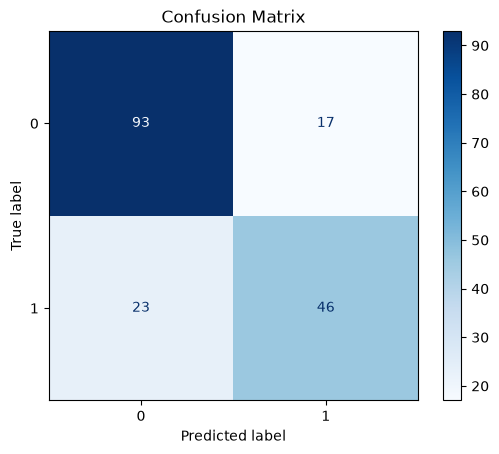

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_prepared,
    y_test,
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.savefig("../outputs/plots/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations

- The model correctly classified **93** passengers who did not survive and **46** passengers who survived.
- It incorrectly predicted **17** non-survivors as survivors (False Positives).
- It incorrectly predicted **23** survivors as non-survivors (False Negatives).
- The model performs better at identifying non-survivors than survivors, which is expected given the class imbalance in the dataset.

## 10.2 Classification Report

The classification report provides a detailed evaluation of the model using precision, recall, F1-score, and support for each class. These metrics help assess how effectively the model identifies each class beyond overall accuracy.

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.73      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.78      0.77       179



### Observations

- The model achieved higher precision, recall, and F1-score for the **non-survivor (Class 0)** category than for the **survivor (Class 1)** category.
- The recall of **67%** for survivors indicates that the model missed some passengers who actually survived.
- The weighted average F1-score of **77%** suggests that the Logistic Regression model provides balanced overall performance on the Titanic dataset.
- Overall, the model generalizes well but performs slightly better on the majority class (non-survivors).

## 10.3 Feature Coefficient Analysis

Logistic Regression assigns a coefficient to each feature, indicating its influence on the prediction. Positive coefficients increase the likelihood of survival, while negative coefficients decrease it. Analyzing these coefficients helps interpret which features have the greatest impact on the model's decisions.

           Feature  Coefficient
2  cat__Sex_female     1.020249
1        num__Fare     0.514643
4  cat__Embarked_C     0.253509
5  cat__Embarked_Q    -0.000324
0         num__Age    -0.156597
6  cat__Embarked_S    -0.252866
3    cat__Sex_male    -1.019930


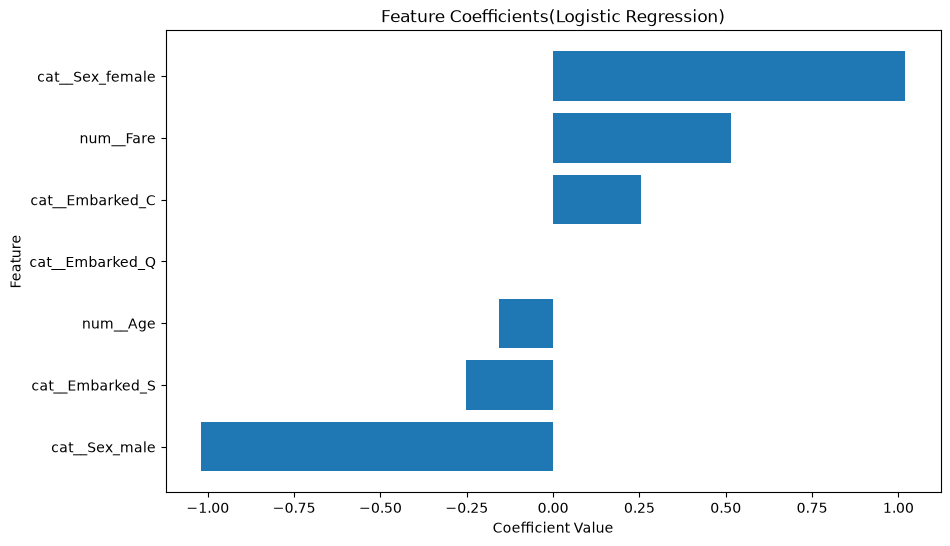

In [30]:
feature_names = preprocessor.get_feature_names_out()
coefficients = best_model.coef_[0]
coef_df=pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)
print(coef_df)

plt.figure(figsize=(10, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Feature Coefficients(Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Observations

- **Sex** was the most influential feature in the model. Female passengers had a significantly higher probability of survival, while male passengers had a significantly lower probability.
- **Fare** had the second strongest positive coefficient, indicating that passengers who paid higher fares were more likely to survive.
- **Age** showed a small negative coefficient, suggesting that older passengers had a slightly lower chance of survival.
- Overall, the learned feature coefficients are consistent with the patterns observed during the exploratory data analysis, indicating that the Logistic Regression model captured meaningful relationships within the dataset

## Save the Model

The trained Logistic Regression model and preprocessing pipeline are saved so they can be reused later for inference or deployment without retraining.

In [31]:
import joblib
from pathlib import Path

# Create models directory if it doesn't exist
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Save artifacts
joblib.dump(best_model, MODELS_DIR / "logistic_regression_model.pkl")
joblib.dump(preprocessor, MODELS_DIR / "preprocessor.pkl")

['..\\models\\preprocessor.pkl']